# Antibody lineage pre-filtering figure

Panels C and D of the combined TCRdist/antibody figure. Reads
`../data/antibody_benchmark_results.json`, produced by
`benchmarks/05_antibody_lineages.ipynb`.

In [1]:
import json

import numpy as np
import matplotlib.pyplot as plt
import pyrepseq as prs

plt.style.use('bmh')

DATADIR = '../data/'

In [ ]:
with open(f'{DATADIR}/antibody_benchmark_results.json') as f:
    results = json.load(f)
# json keys are always strings, so cast max_edits keys back to int
times_symscan = {int(k): v for k, v in results['times_symscan'].items()}
fractions = {int(k): v for k, v in results['fractions'].items()}
time_exhaustive = results['time_exhaustive']
max_editss = results['max_editss']

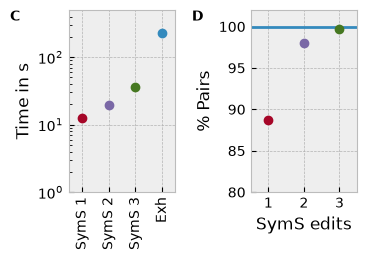

In [3]:
fig, axes = plt.subplots(figsize=(3.42, 2.4), ncols=2)
for max_edits in max_editss:
    axes[0].plot(f'SymS {max_edits}', np.sum(times_symscan[max_edits]), 'o', color=f'C{max_edits}')
    axes[1].plot([max_edits], [np.mean(fractions[max_edits])*100], 'o', color=f'C{max_edits}', zorder=3)
axes[0].plot('Exh', [time_exhaustive], 'o', color='C0')
axes[0].tick_params(axis='x', labelrotation=90)
axes[0].set_ylabel('Time in s')
axes[0].set_yscale('log')
axes[0].set_ylim(1e0, 5e2)
axes[0].set_xlim(-0.5, 3.5)
axes[1].axhline(y=100, color='C0', ls='-', zorder=2)
axes[1].set_xlabel('SymS edits')
axes[1].set_ylabel('% Pairs')
axes[1].set_ylim(80, 102)
axes[1].set_xlim(0.5, 3.5)
fig.tight_layout(w_pad=1.5, pad=0.0)
prs.plotting.label_axes(fig, xy=(-0.55, 1.0), labels='CD')
fig.savefig('antibody_benchmark.svg')